# Phase 1: Exploratory Data Analysis & Data Preprocessing

In this notebook, we will load the datasets files, inspect the target variable `liquidity_stress_next_30d`, and analyze the features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# load data
train_df = pd.read_csv('../data/Train.csv')
test_df = pd.read_csv('../data/Test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (40000, 184)
Test shape: (30000, 183)


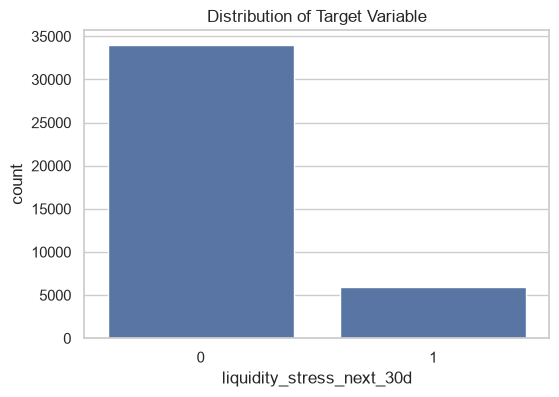

liquidity_stress_next_30d
0    0.85
1    0.15
Name: proportion, dtype: float64


In [ ]:
# analyze Target Variable
target = 'liquidity_stress_next_30d'

plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x=target)
plt.title('Distribution of Target Variable')
plt.show()

print(train_df[target].value_counts(normalize=True))

## Missing Values and Data Types
checking if we have any missing values or if we need to encode categorical variables.

In [ ]:
print("Missing values in Train:", train_df.isnull().sum().max())
print("Missing values in Test:", test_df.isnull().sum().max())

# identify Categorical Columns
cat_cols = [col for col in train_df.columns if train_df[col].dtype == 'object' and col != 'ID']
print("\nCategorical Columns:", cat_cols)

for col in cat_cols:
    print(f"-- {col}: {train_df[col].nunique()} unique values")

Missing values in Train: 0
Missing values in Test: 0

Categorical Columns: ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']
-- gender: 2 unique values
-- region: 7 unique values
-- smartphone: 2 unique values
-- segment: 3 unique values
-- earning_pattern: 3 unique values


Since the cardinality of our categorical variables is very low (max 7 unique values), one-hot encoding is a great choice here.

In [ ]:
# concatenate train and test for consistent encoding
n_train = train_df.shape[0]
all_data = pd.concat([train_df, test_df], ignore_index=True)

# 0ne-Hot Encoding
all_data = pd.get_dummies(all_data, columns=cat_cols, drop_first=True)

train_clean = all_data.iloc[:n_train].copy()
test_clean = all_data.iloc[n_train:].copy()
test_clean.drop(columns=[target], inplace=True)

print(f"Cleaned Train shape: {train_clean.shape}")
print(f"Cleaned Test shape: {test_clean.shape}")

Cleaned Train shape: (40000, 191)
Cleaned Test shape: (30000, 190)


## Save the Cleaned Baseline Dataset
save the cleaned datasets as Parquet files. Parquet is much faster to load than CSV and preserves data types perfectly

In [5]:
import os
os.makedirs('../data/cleaned', exist_ok=True)

# Save as parquet
train_clean.to_parquet('../data/cleaned/train_clean.parquet', index=False, engine='fastparquet')
test_clean.to_parquet('../data/cleaned/test_clean.parquet', index=False, engine='fastparquet')

print("Saved cleaned datasets to data/cleaned/")

Saved cleaned datasets to data/cleaned/
